# Validation croisée

Réf: https://scikit-learn.org/stable/modules/cross_validation.html

     https://blent.ai/blog/a/validation-croisee-machine-learning

Apprendre les paramètres d'une fonction de prédiction et la tester sur les mêmes données est une erreur méthodologique : un modèle qui se contenterait de répéter les étiquettes des échantillons qu'il vient de voir obtiendrait un score parfait, mais ne parviendrait pas à prédire quoi que ce soit d'utile sur des données encore inconnues. Cette situation est appelée "overfitting". Pour l'éviter, il est courant, lors d'une expérience d'apprentissage automatique (supervisée), de conserver une partie des données disponibles comme ensemble de test X_test, y_test. Pour ce faire, la validation croisée est fréquenmment utilisée. 

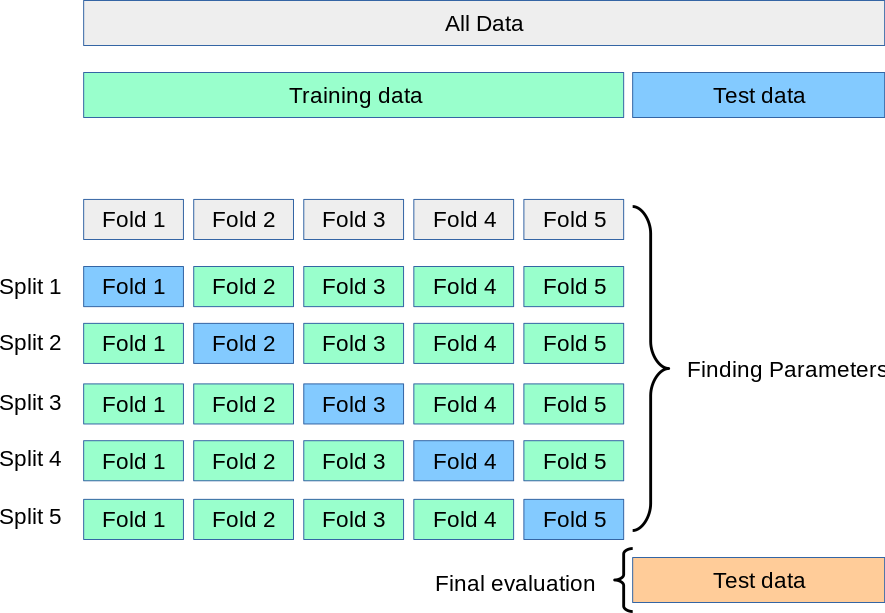


Nous allons implémenter cette technique dans un exemple simple

0. Charger les librairies nécessaires et la base de données "California_housing_data.csv"


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('California_housing_data.csv')
df.head()

,Unnamed: 0,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,price
0,0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
data = df.drop(columns=['Unnamed: 0','price']) 
target = df['price']

In [4]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
target *= 100 # pour avoir le prix en k$
target.head()

0    452.6
1    358.5
2    352.1
3    341.3
4    342.2
Name: price, dtype: float64

1. Analyser la base de données 

Vous êtes libres à donner la réponse. Suggestions: afficher par exemple les statistiques de données, hitogramme, pairplot...

On va ensuite étudier le modèle "arbre de décision" pour prédire le prix de la maison

Quelques informations sur ce modèle:
https://scikit-learn.org/stable/modules/tree.html

A noter que l'objet de cette étude est la validation croisée, pas besoin de tout comprendre sur les arbres de décision pour le moment. Ce modèle sera abordé plus tard dans l'UE.

2. Séparation train/test

In [6]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target
)

3. Entrainer l'arbre de décision avec les données "train"

In [7]:
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor()
regressor.fit(data_train, target_train)

DecisionTreeRegressor()

4. Afficher MAE pour train et pour test. Votre remarque?

In [8]:
from sklearn.metrics import mean_absolute_error

target_predicted = regressor.predict(data_train)
score = mean_absolute_error(target_train, target_predicted)
print(f"The training error of our model is {score:.2f} k$")

The training error of our model is 0.00 k$


In [9]:
target_predicted = regressor.predict(data_test)
score = mean_absolute_error(target_test, target_predicted)
print(f"The testing error of our model is {score:.2f} k$")

The testing error of our model is 44.94 k$


5. Refaire les questions 2-3-4 mais avec une séparation train/test différente (changer random_state). Que remarquez-vous sur les valeurs MAE obtenues de la question 4 pour ces 2 lancements

In [10]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target
)
regressor.fit(data_train, target_train)


DecisionTreeRegressor()

In [11]:
target_predicted = regressor.predict(data_train)
score = mean_absolute_error(target_train, target_predicted)
print(f"The training error of our model is {score:.2f} k$")

The training error of our model is 0.00 k$


In [12]:
target_predicted = regressor.predict(data_test)
score = mean_absolute_error(target_test, target_predicted)
print(f"The testing error of our model is {score:.2f} k$")

The testing error of our model is 47.87 k$


remarques: MAE sur test change à chaque fois

6. Pour mieux évaluer les performances du modèle dans le cas général, on va utiliser cross_validate

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate



In [13]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    regressor, data, target, cv=20, scoring="neg_mean_absolute_error"
)

In [14]:
print(cv_results)

{'fit_time': array([0.62630224, 0.55857968, 0.62616467, 0.653651  , 0.59934092,
       0.66749191, 0.55985403, 0.65388989, 0.64271975, 0.64233398,
       0.61775804, 0.5670774 , 0.59298897, 0.57677245, 0.54268932,
       0.58501744, 0.65363026, 0.59052277, 0.64002395, 0.54175115]), 'score_time': array([0.        , 0.0131886 , 0.01339412, 0.        , 0.        ,
       0.01320863, 0.        , 0.0132246 , 0.        , 0.01249528,
       0.        , 0.01212025, 0.01227331, 0.        , 0.        ,
       0.00762343, 0.01238084, 0.        , 0.00106215, 0.01230359]), 'test_score': array([-102.13187016,  -55.86939922,  -47.26474903,  -58.00015019,
        -58.0205969 ,  -60.81811822,  -44.24044864,  -45.41473643,
        -69.86377616,  -59.79791182,  -56.59194089,  -54.6007064 ,
        -45.18304942,  -48.77637016,  -52.3262907 ,  -82.80704845,
        -82.64066182,  -61.23135659,  -53.07587694,  -48.18345833])}


7. Construire un dataframe à partir de cv_results, afficher-le

In [15]:
import pandas as pd

cv_results = pd.DataFrame(cv_results)
cv_results.head()

,fit_time,score_time,test_score
0,0.626302,0.000000,-102.131870
1,0.558580,0.013189,-55.869399
2,0.626165,0.013394,-47.264749
3,0.653651,0.000000,-58.000150
4,0.599341,0.000000,-58.020597


8. Ajouter une colonne, nommée "test_error" en reprenant la colonne "test_score" mais en mettant le signe "-" devant chaque valeur. Afficher le dataframe modifié qui contient désormais 4 colonnes

In [16]:
cv_results["test_error"] = -cv_results["test_score"]

In [17]:
cv_results.head(10)

,fit_time,score_time,test_score,test_error
0,0.626302,0.000000,-102.131870,102.131870
1,0.558580,0.013189,-55.869399,55.869399
2,0.626165,0.013394,-47.264749,47.264749
3,0.653651,0.000000,-58.000150,58.000150
4,0.599341,0.000000,-58.020597,58.020597
5,0.667492,0.013209,-60.818118,60.818118
6,0.559854,0.000000,-44.240449,44.240449
7,0.653890,0.013225,-45.414736,45.414736
8,0.642720,0.000000,-69.863776,69.863776
9,0.642334,0.012495,-59.797912,59.797912


9. Tracer l'histogramme des erreurs MAE

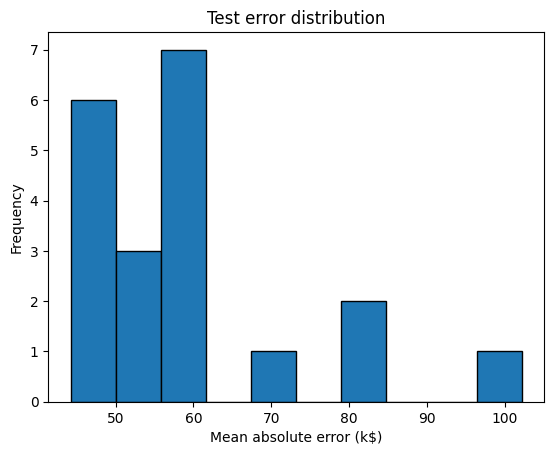

In [18]:
import matplotlib.pyplot as plt

cv_results["test_error"].plot.hist(bins=10, edgecolor="black")
plt.xlabel("Mean absolute error (k$)")
_ = plt.title("Test error distribution")

In [19]:
print(
    "The mean cross-validated testing error is: "
    f"{cv_results['test_error'].mean():.2f} k$"
)

The mean cross-validated testing error is: 59.34 k$


In [20]:
print(
    "The standard deviation of the testing error is: "
    f"{cv_results['test_error'].std():.2f} k$"
)

The standard deviation of the testing error is: 14.83 k$


10. En traçant l'histogramme des prix de maisons, commenter sur les performances du modèle 'decision tree'

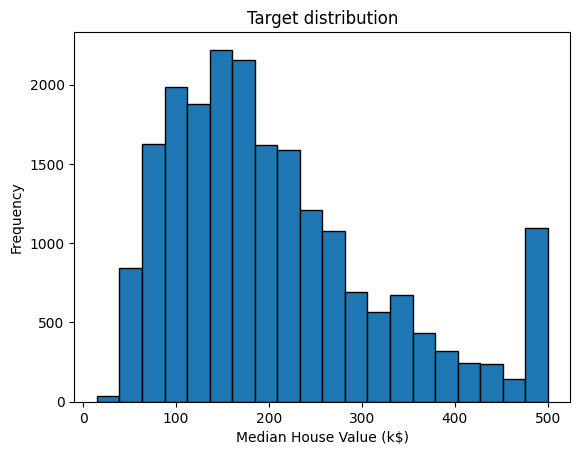

In [21]:
target.plot.hist(bins=20, edgecolor="black")
plt.xlabel("Median House Value (k$)")
_ = plt.title("Target distribution")

In [22]:
print(f"The standard deviation of the target is: {target.std():.2f} k$")

The standard deviation of the target is: 115.40 k$
